# Definite Numerical Integration

In contrast to cumulative numerical integration, definite numerical integration is used when the objective is to obtain a single scalar value over a specified interval or domain. The general form of a one-dimensional definite integral is

$$
\int_{a}^{b}f(x)\,dx,
$$

which represents the total contribution of the function between the lower limit $a$ and the upper limit $b$. Unlike cumulative integration, the result is a single number rather than a function that evolves with the independent variable. This notebook demonstrates definite numerical integration in both one-dimensional (1D) and two-dimensional (2D) problems.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson, trapezoid, romb, quad, dblquad

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

# One Dimension

For a sinusoidal voltage waveform

$$
V(t)=V_0\sin(\omega t),
$$

the root-mean-square (RMS) voltage over one period $T$ is

$$
V_{rms}=\sqrt{\frac{1}{T}\int_{0}^{t}V(t)^2\,dt}.
$$

The integral is evaluated numerically using several methods.

In [3]:
V0, f = 220 * np.sqrt(2), 50
omega, T = 2 * np.pi * f, 1 / f
V = lambda t: V0 * np.sin(omega * t)
t, dt = np.linspace(0, T, 2**8 + 1, retstep=True)

The definite integral in one dimension is approximated using the trapezoidal rule, Simpson's rule, Romberg integration, and adaptive quadrature. In this notebook, these methods are implemented using `scipy.integrate.trapezoid`, `scipy.integrate.simpson`, `scipy.integrate.romb`, and `scipy.integrate.quad`.

In [4]:
print("RMS (trapezoid):", np.sqrt(trapezoid(V(t)**2, t) / T))

RMS (trapezoid): 220.0


In [5]:
print("RMS (simpson):", np.sqrt(simpson(V(t)**2, t) / T))

RMS (simpson): 220.0


In [6]:
print("RMS (romb):", np.sqrt(romb(V(t)**2, dx=dt) / T))

RMS (romb): 220.0


In [7]:
print("RMS (quad):", np.sqrt(quad(lambda t: V(t)**2, 0, T)[0] / T))

RMS (quad): 220.0


## Two Dimensions

A spatial intensity distribution is defined as

$$
I(x,y)=1000\left(x+1\right)^{-2}\left(y+1\right)^{-2}.
$$

The total power over the rectangular region $0\leq x\leq 1$ and $0\leq y\leq 1$ is obtained from the double integral

$$
P=\int_{0}^{1}\int_{0}^{1}I(x,y)\,dx\,dy
$$

This example illustrates how numerical integration can be extended from one dimension to two dimensions.

In [8]:
x_min, x_max = 0, 1
y_min, y_max = 0, 1
x = np.linspace(x_min, x_max, 200)
y = np.linspace(y_min, y_max, 200)
X, Y = np.meshgrid(x, y)
Z = 1000 * (X + 1)**-2 * (Y + 1)**-2
I = lambda y, x: 1000 * (x + 1)**-2 * (y + 1)**-2

The two-dimensional definite integral is approximated using nested Simpson integration and Adaptive Double Quadrature. In this notebook, these methods are implemented using `scipy.integrate.simpson` applied sequentially along both axes and `scipy.integrate.dblquad`.

In [9]:
print("Total Power (simpson):", simpson(simpson(Z, y, axis=0), x))

Total Power (simpson): 250.0000000621775


In [10]:
print("Total Power (dblquad):", dblquad(I, x_min, x_max, y_min, y_max)[0])

Total Power (dblquad): 249.99999999999997


The contour plot displays the spatial intensity distribution $I(x,y)$ over the integration domain. Brighter regions correspond to higher intensity values, while darker regions indicate lower intensity. The numerical integration methods compute the total power represented by the entire area under this surface.

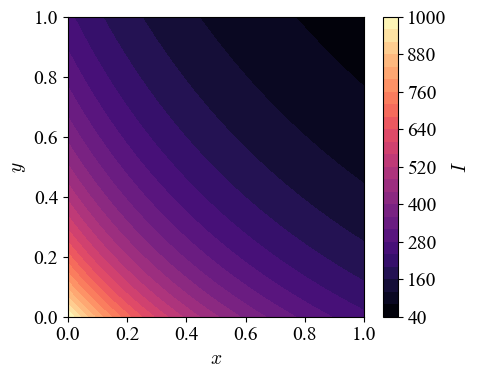

In [11]:
plt.figure(figsize=(5, 4))
plt.contourf(X, Y, Z, 25, cmap="magma")
plt.colorbar(label=r"$I$")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.tight_layout()
plt.show()

## Key Insight

* Definite numerical integration returns a single scalar value representing the total contribution of a function over a specified interval or domain.
* Trapezoidal, Simpson, Romberg, and adaptive quadrature methods produce closely matching results, demonstrating good numerical consistency.
* In the 2D example, numerical integration is extended from a line integral to a surface integral to obtain the total integrated quantity over a rectangular region.
* The close agreement between nested Simpson integration and dblquad demonstrates the reliability of both fixed-grid and adaptive approaches for two-dimensional problems.